In [668]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    log_loss,
    matthews_corrcoef,
    cohen_kappa_score,
    balanced_accuracy_score,
    hamming_loss,
    jaccard_score,
    zero_one_loss
)
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline 

<a id="dataset_overview"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Google Play Store Apps Dataset Overview</b></div>

This dataset contains information about various mobile applications listed on the Google Play Store. It includes app metadata, user engagement metrics, and app characteristics useful for analysis and prediction tasks.

| Column Name      | Description                                               |
|------------------|-----------------------------------------------------------|
| App              | Name of the application                                   |
| Category         | Category under which the app is listed                    |
| Rating           | Average user rating (out of 5)                            |
| Reviews          | Total number of user reviews                              |
| Size             | Size of the app (in MB or KB)                             |
| Installs         | Number of times the app has been installed                |
| Type             | Whether the app is Free or Paid                           |
| Price            | Price of the app (0 if free)                              |
| Content Rating   | Audience classification (Everyone, Teen, etc.)           |
| Genres           | App genre(s)                                             |
| Last Updated     | Last update date of the app                               |
| Current Ver      | Current version of the app                                |
| Android Ver      | Minimum Android version required                           |

---

## Sample Data Preview

| App                                    | Category      | Rating | Reviews | Size | Installs | Type | Price | Content Rating | Genres           | Last Updated | Current Ver | Android Ver    |
|---------------------------------------|---------------|--------|---------|------|----------|------|-------|----------------|------------------|--------------|-------------|---------------|
| Photo Editor & Candy Camera & Grid ...| ART_AND_DESIGN| 4.1    | 159     | 19M  | 10,000+  | Free | 0     | Everyone       | Art & Design     | 07-Jan-18    | 1.0.0       | 4.0.3 and up  |
| Coloring book moana                   | ART_AND_DESIGN| 3.9    | 967     | 14M  | 500,000+ | Free | 0     | Everyone       | Art & Design;Pretend Play | 15-Jan-18    | 2.0.0       | 4.0.3 and up  |

---

This dataset is ideal for tasks such as rating prediction, popularity analysis and app category clustering.

In [669]:
df=pd.read_csv("/kaggle/input/google-playstore-data/googleplaystore.csv")

In [670]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,07-Jan-18,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,01-Aug-18,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,08-Jun-18,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


In [671]:
df.drop(columns=["App"],axis=1,inplace=True)

In [672]:
df.shape

(10841, 12)

In [673]:
df.isnull().sum()

Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

<a id="missing_values_handling"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Handling Missing Values for Additional Columns</b></div>

In [674]:
mean=df["Rating"].mean()
df["Rating"]=df["Rating"].fillna(mean)

mode=df["Type"].mode()[0]
df["Type"]=df["Type"].fillna(mode)

mode=df["Content Rating"].mode()[0]
df["Content Rating"]=df["Content Rating"].fillna(mode)

mode=df["Current Ver"].mode()[0]
df["Current Ver"]=df["Current Ver"].fillna(mode)

mode=df["Android Ver"].mode()[0]
df["Android Ver"]=df["Android Ver"].fillna(mode)

In [675]:
df.isnull().sum()

Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

<a id="date_size_processing"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Date and Size Processing</b></div>

In [676]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'], format='%d-%b-%y', errors='coerce')

df['Last_Updated_Year'] = df['Last Updated'].dt.year
df['Last_Updated_Month'] = df['Last Updated'].dt.month
df['Last_Updated_Day'] = df['Last Updated'].dt.day
df['Last_Updated_DayOfWeek'] = df['Last Updated'].dt.dayofweek
df['Days_Since_Last_Update'] = (pd.to_datetime('today') - df['Last Updated']).dt.days


def clean_size(size):
    if pd.isna(size) or size == 'Varies with device':
        return np.nan
    elif 'M' in size:
        return float(size.replace('M', '').strip())
    elif 'k' in size:
        return float(size.replace('k', '').strip()) / 1024  # convert KB to MB
    else:
        return np.nan

df['Size'] = df['Size'].apply(clean_size)



In [677]:
df.drop(columns=["Last Updated"],axis=1,inplace=True)

<a id="data_transformation"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Data Transformation: Cleaning and Formatting</b></div>

In [678]:
df['Installs'] = df['Installs'].str.replace('[+,]', '', regex=True)
df = df[df['Installs'].str.isnumeric()]
df['Installs'] = df['Installs'].astype(int)
df['Price'] = df['Price'].replace('[\$,]', '', regex=True).astype(float)
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Reviews'] = df['Reviews'].astype(int)

def clean_version(ver):
    if pd.isna(ver) or 'varies' in str(ver).lower():
        return np.nan
    
    # Extract the first occurrence of a version pattern like 'x.y' or 'x.y.z'
    match = re.search(r'(\d+)\.(\d+)', str(ver))
    if match:
        major, minor = match.groups()
        try:
            return float(f"{major}.{minor}")
        except ValueError:
            return np.nan
    else:
        # Try to convert just the first number if possible
        first_num = re.match(r'\d+', str(ver))
        if first_num:
            return float(first_num.group())
    
    return np.nan

df['Current Ver'] = df['Current Ver'].apply(clean_version)

median_ver = df['Current Ver'].median()
df['Current Ver'].fillna(median_ver, inplace=True)


def clean_android_ver(ver):
    if pd.isna(ver) or 'varies' in str(ver).lower():
        return np.nan
    
    # Extract version number before any space or text (e.g. '4.0.3 and up' → '4.0.3')
    ver_str = str(ver).split(' ')[0]
    
    # Extract major.minor as float
    match = re.match(r'(\d+)\.(\d+)', ver_str)
    if match:
        major, minor = match.groups()
        return float(f"{major}.{minor}")
    
    # If no match, try to convert first number alone
    first_num = re.match(r'\d+', ver_str)
    if first_num:
        return float(first_num.group())
    
    return np.nan

df['Android Ver'] = df['Android Ver'].apply(clean_android_ver)


In [679]:
df.head()

,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Last_Updated_Year,Last_Updated_Month,Last_Updated_Day,Last_Updated_DayOfWeek,Days_Since_Last_Update
0,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,1.0,4.0,2018.0,1.0,7.0,6.0,2760.0
1,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2.0,4.0,2018.0,1.0,15.0,0.0,2752.0
2,ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,1.2,4.0,2018.0,8.0,1.0,2.0,2554.0
3,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2.0,4.2,2018.0,6.0,8.0,4.0,2608.0
4,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,1.1,4.4,2018.0,6.0,20.0,2.0,2596.0


<a id="Data Cleaning"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Data Cleaning: Handling Missing Values</b></div>

In [680]:
mean=df["Size"].mean()
df["Size"]=df["Size"].fillna(mean)

mean=df["Android Ver"].mean()
df["Android Ver"]=df["Android Ver"].fillna(mean)

mean=df["Days_Since_Last_Update"].mean()
df["Days_Since_Last_Update"]=df["Days_Since_Last_Update"].fillna(mean)

mode=df["Last_Updated_Year"].mode()[0]
df["Last_Updated_Year"]=df["Last_Updated_Year"].fillna(mean)

mode=df["Last_Updated_Month"].mode()[0]
df["Last_Updated_Month"]=df["Last_Updated_Month"].fillna(mean)

mode=df["Last_Updated_Day"].mode()[0]
df["Last_Updated_Day"]=df["Last_Updated_Day"].fillna(mean)


mode=df["Last_Updated_DayOfWeek"].mode()[0]
df["Last_Updated_DayOfWeek"]=df["Last_Updated_DayOfWeek"].fillna(mean)

<a id="vis1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Visualization 1: Histogram of Ratings</b></div>


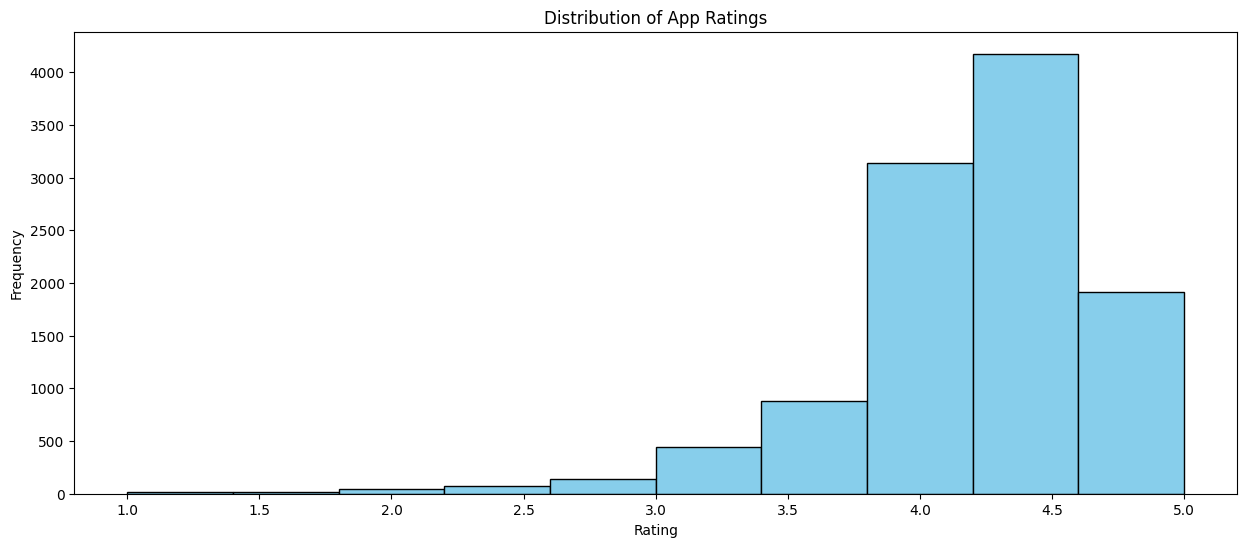

In [681]:
plt.figure(figsize=(15, 6))
plt.hist(df['Rating'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

<a id="vis2"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Visualization 2: Box Plot of Reviews</b></div>


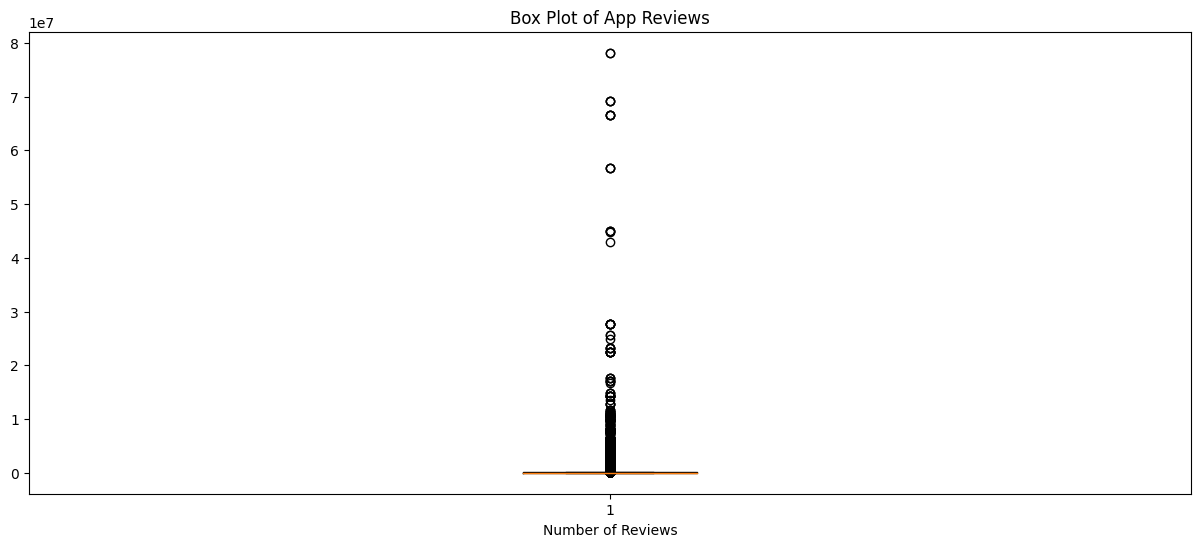

In [682]:
plt.figure(figsize=(15, 6))
plt.boxplot(df['Reviews'], vert=True)
plt.title('Box Plot of App Reviews')
plt.xlabel('Number of Reviews')
plt.show()

<a id="vis3"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Visualization 3: Scatter Plot of Reviews vs Installs</b></div>


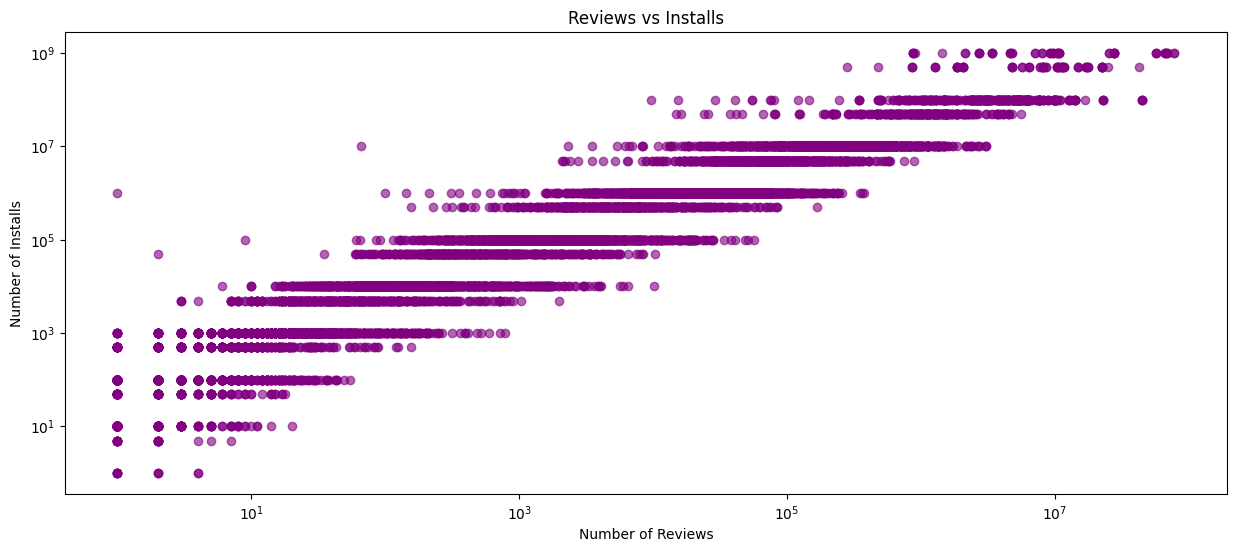

In [683]:
plt.figure(figsize=(15, 6))
plt.scatter(df['Reviews'], df['Installs'], color='purple', alpha=0.6)
plt.title('Reviews vs Installs')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Installs')
plt.xscale('log')
plt.yscale('log')
plt.show()

<a id="vis4"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Visualization 4: Bar Plot of Content Rating Counts</b></div>

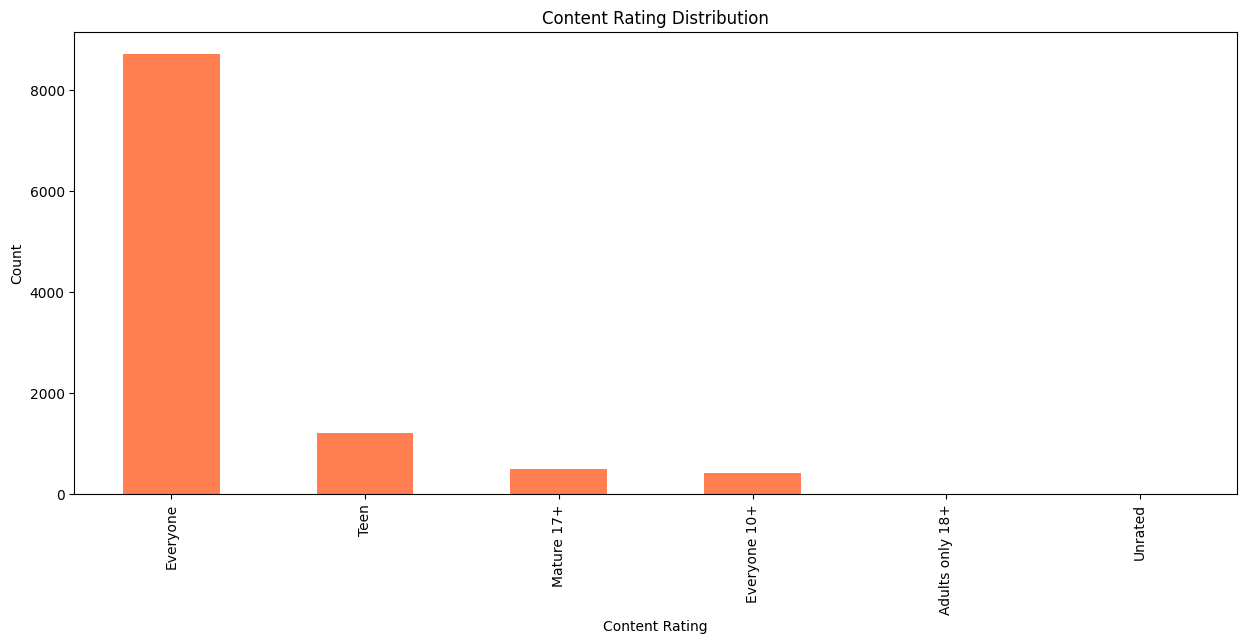

In [684]:
plt.figure(figsize=(15, 6))
df['Content Rating'].value_counts().plot(kind='bar', color='coral')
plt.title('Content Rating Distribution')
plt.xlabel('Content Rating')
plt.ylabel('Count')
plt.show()

<a id="vis5"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Visualization 5: Correlation Heatmap</b></div>

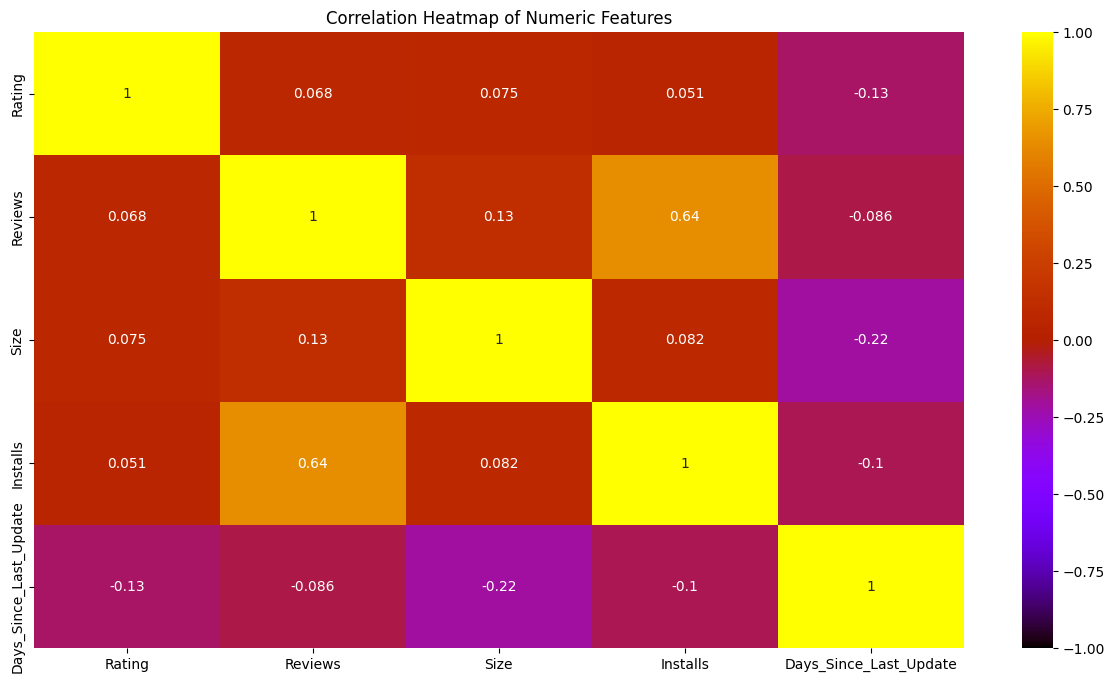

In [685]:
numeric_cols = ['Rating', 'Reviews', 'Size', 'Installs', 'Days_Since_Last_Update']
plt.figure(figsize=(15, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='gnuplot', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

<a id="vis6"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Visualization 6: Scatter Plot of Size vs Rating</b></div>


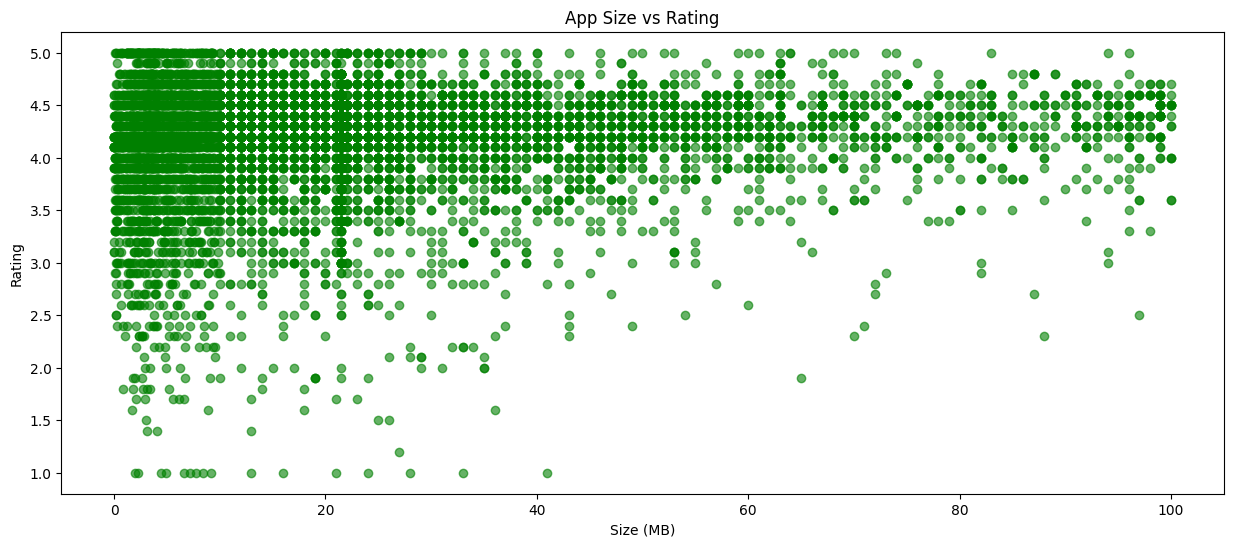

In [686]:
plt.figure(figsize=(15, 6))
plt.scatter(df['Size'], df['Rating'], color='green', alpha=0.6)
plt.title('App Size vs Rating')
plt.xlabel('Size (MB)')
plt.ylabel('Rating')
plt.show()

<a id="vis7"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Visualization 7: Bar Plot of Average Rating by Content Rating</b></div>

---

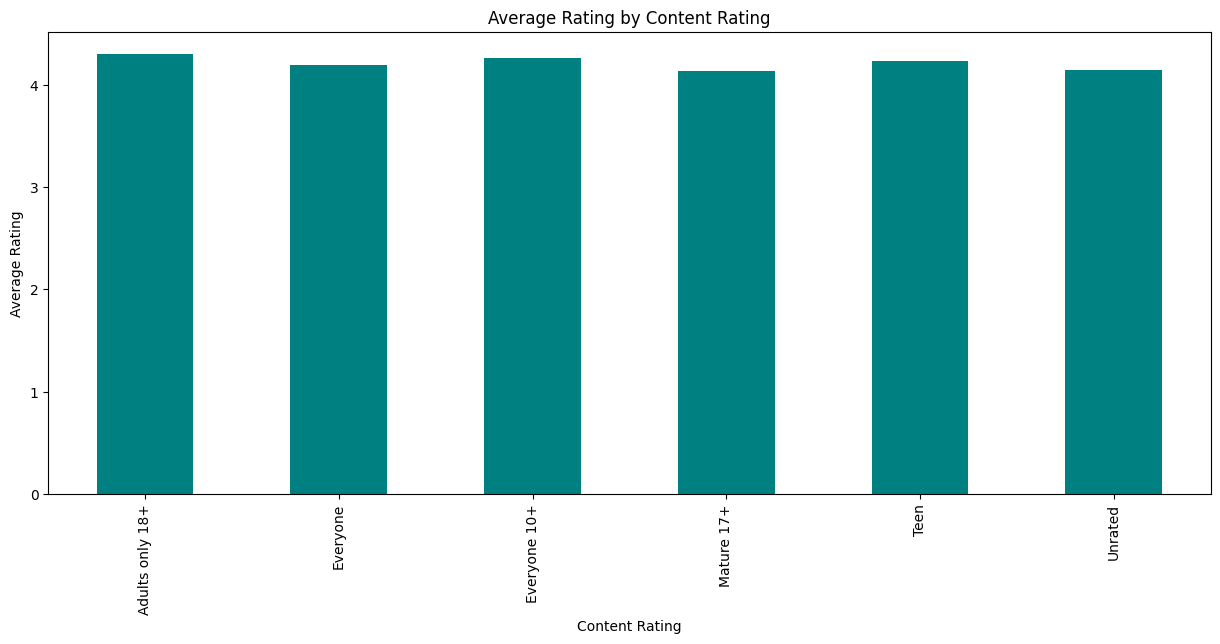

In [687]:
plt.figure(figsize=(15, 6))
df.groupby('Content Rating')['Rating'].mean().plot(kind='bar', color='teal')
plt.title('Average Rating by Content Rating')
plt.xlabel('Content Rating')
plt.ylabel('Average Rating')
plt.show()

<a id="vis8"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Visualization 8: Histogram of Days Since Last Update</b></div>


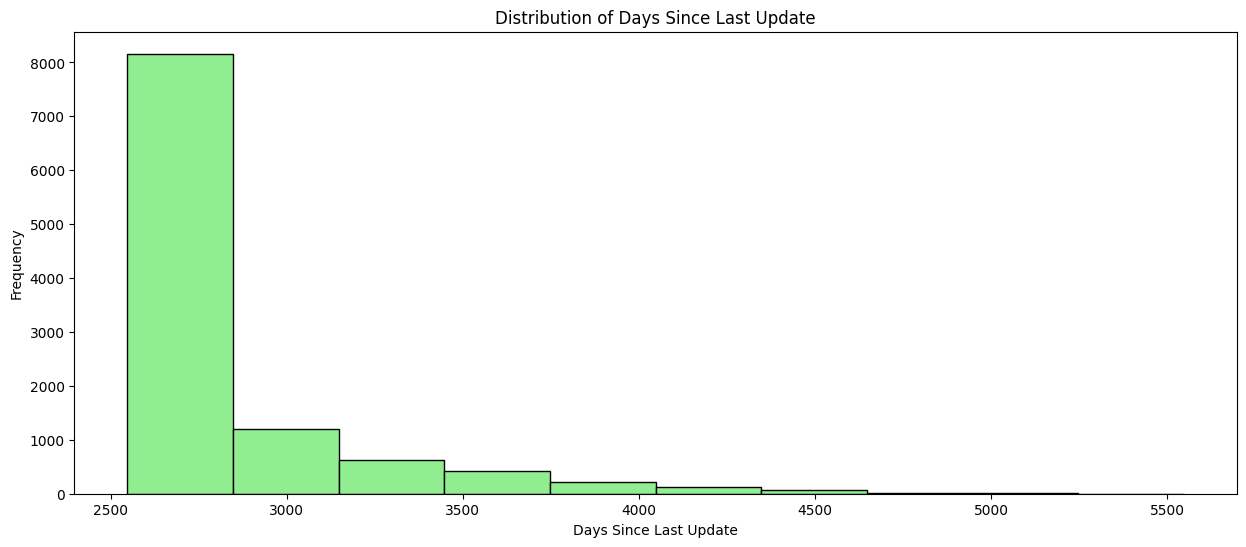

In [688]:
plt.figure(figsize=(15, 6))
plt.hist(df['Days_Since_Last_Update'], bins=10, color='lightgreen', edgecolor='black')
plt.title('Distribution of Days Since Last Update')
plt.xlabel('Days Since Last Update')
plt.ylabel('Frequency')
plt.show()

<a id="vis9"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Visualization 9: Scatter Plot of Days Since Last Update vs Rating</b></div>

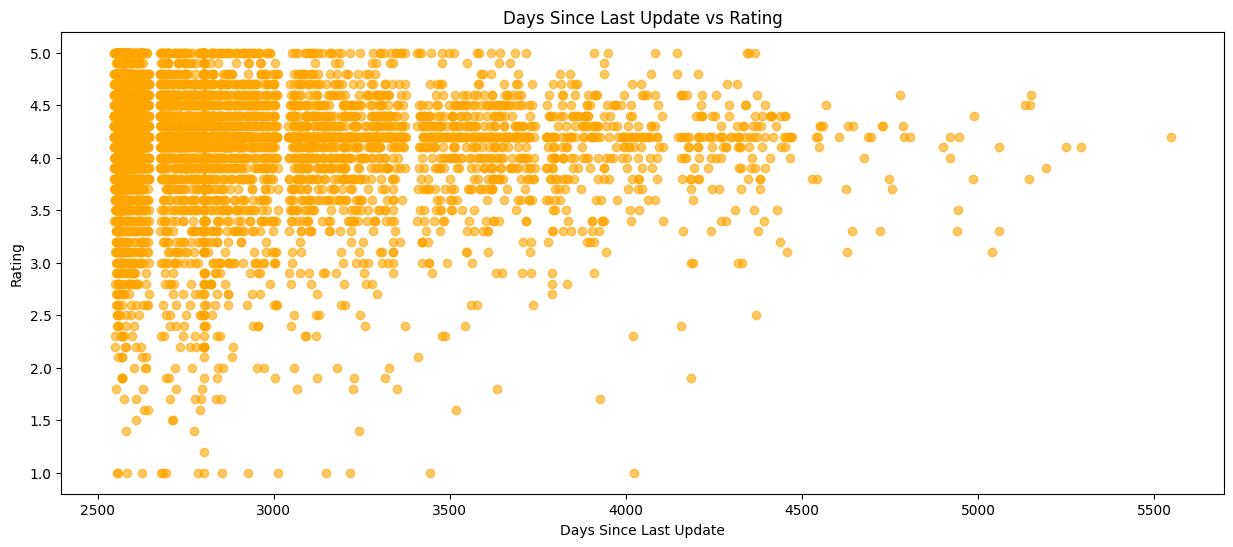

In [689]:
plt.figure(figsize=(15, 6))
plt.scatter(df['Days_Since_Last_Update'], df['Rating'], color='orange', alpha=0.6)
plt.title('Days Since Last Update vs Rating')
plt.xlabel('Days Since Last Update')
plt.ylabel('Rating')
plt.show()

In [690]:
df.head()

,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Last_Updated_Year,Last_Updated_Month,Last_Updated_Day,Last_Updated_DayOfWeek,Days_Since_Last_Update
0,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,1.0,4.0,2018.0,1.0,7.0,6.0,2760.0
1,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2.0,4.0,2018.0,1.0,15.0,0.0,2752.0
2,ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,1.2,4.0,2018.0,8.0,1.0,2.0,2554.0
3,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2.0,4.2,2018.0,6.0,8.0,4.0,2608.0
4,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,1.1,4.4,2018.0,6.0,20.0,2.0,2596.0


<a id="label_encoding"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Label Encoding Categorical Columns</b></div>

In [691]:
from sklearn.preprocessing import LabelEncoder


col = ["Category", "Type", "Content Rating", "Genres"]
label_encoders = {}

for c in col:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c])
    label_encoders[c] = le
    print(f"Encoding for '{c}':")
    for i, class_ in enumerate(le.classes_):
        print(f"  {class_} => {i}")
    print()


Encoding for 'Category':
  ART_AND_DESIGN => 0
  AUTO_AND_VEHICLES => 1
  BEAUTY => 2
  BOOKS_AND_REFERENCE => 3
  BUSINESS => 4
  COMICS => 5
  COMMUNICATION => 6
  DATING => 7
  EDUCATION => 8
  ENTERTAINMENT => 9
  EVENTS => 10
  FAMILY => 11
  FINANCE => 12
  FOOD_AND_DRINK => 13
  GAME => 14
  HEALTH_AND_FITNESS => 15
  HOUSE_AND_HOME => 16
  LIBRARIES_AND_DEMO => 17
  LIFESTYLE => 18
  MAPS_AND_NAVIGATION => 19
  MEDICAL => 20
  NEWS_AND_MAGAZINES => 21
  PARENTING => 22
  PERSONALIZATION => 23
  PHOTOGRAPHY => 24
  PRODUCTIVITY => 25
  SHOPPING => 26
  SOCIAL => 27
  SPORTS => 28
  TOOLS => 29
  TRAVEL_AND_LOCAL => 30
  VIDEO_PLAYERS => 31
  WEATHER => 32

Encoding for 'Type':
  Free => 0
  Paid => 1

Encoding for 'Content Rating':
  Adults only 18+ => 0
  Everyone => 1
  Everyone 10+ => 2
  Mature 17+ => 3
  Teen => 4
  Unrated => 5

Encoding for 'Genres':
  Action => 0
  Action;Action & Adventure => 1
  Adventure => 2
  Adventure;Action & Adventure => 3
  Adventure;Brain Games

<a id="feature_scaling"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Feature Scaling with MinMaxScaler</b></div>

In [692]:
from sklearn.preprocessing import MinMaxScaler

cols = ["Reviews", "Size", "Installs", "Android Ver", "Days_Since_Last_Update", "Price"]

scaler = MinMaxScaler()
df[cols] = scaler.fit_transform(df[cols])


In [693]:
df.head()

,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Last_Updated_Year,Last_Updated_Month,Last_Updated_Day,Last_Updated_DayOfWeek,Days_Since_Last_Update
0,0,4.1,0.000002,0.189933,0.00001,0,0.0,1,9,1.0,0.428571,2018.0,1.0,7.0,6.0,0.070976
1,0,3.9,0.000012,0.139929,0.00050,0,0.0,1,12,2.0,0.428571,2018.0,1.0,15.0,0.0,0.068311
2,0,4.7,0.001120,0.086924,0.00500,0,0.0,1,9,1.2,0.428571,2018.0,8.0,1.0,2.0,0.002333
3,0,4.5,0.002759,0.249938,0.05000,0,0.0,4,9,2.0,0.457143,2018.0,6.0,8.0,4.0,0.020327
4,0,4.3,0.000012,0.027919,0.00010,0,0.0,1,11,1.1,0.485714,2018.0,6.0,20.0,2.0,0.016328


In [694]:
def convert_to_class(r):
    if r >= 4.5:
        return 'Excellent'
    elif r >= 4.0:
        return 'Good'
    elif r >= 3.0:
        return 'Average'
    else:
        return 'Poor'

df["Rating"] = df["Rating"].apply(convert_to_class)
rating_map = {"Poor": 0,"Average": 1,"Good": 2,"Excellent": 3}
df["Rating"] = df["Rating"].map(rating_map)

<a id="feature_selection"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#008000; overflow:hidden"><b>Feature Selection with SelectKBest</b></div>

In [695]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

X = df.drop(columns=["Rating"])
y = df["Rating"]

selector = SelectKBest(score_func=mutual_info_classif, k=5)
selector.fit(X, y)

mask = selector.get_support()
top_features = X.columns[mask].tolist()
scores = selector.scores_[mask]

new_df = df[top_features].copy()
new_df["Rating"] = y


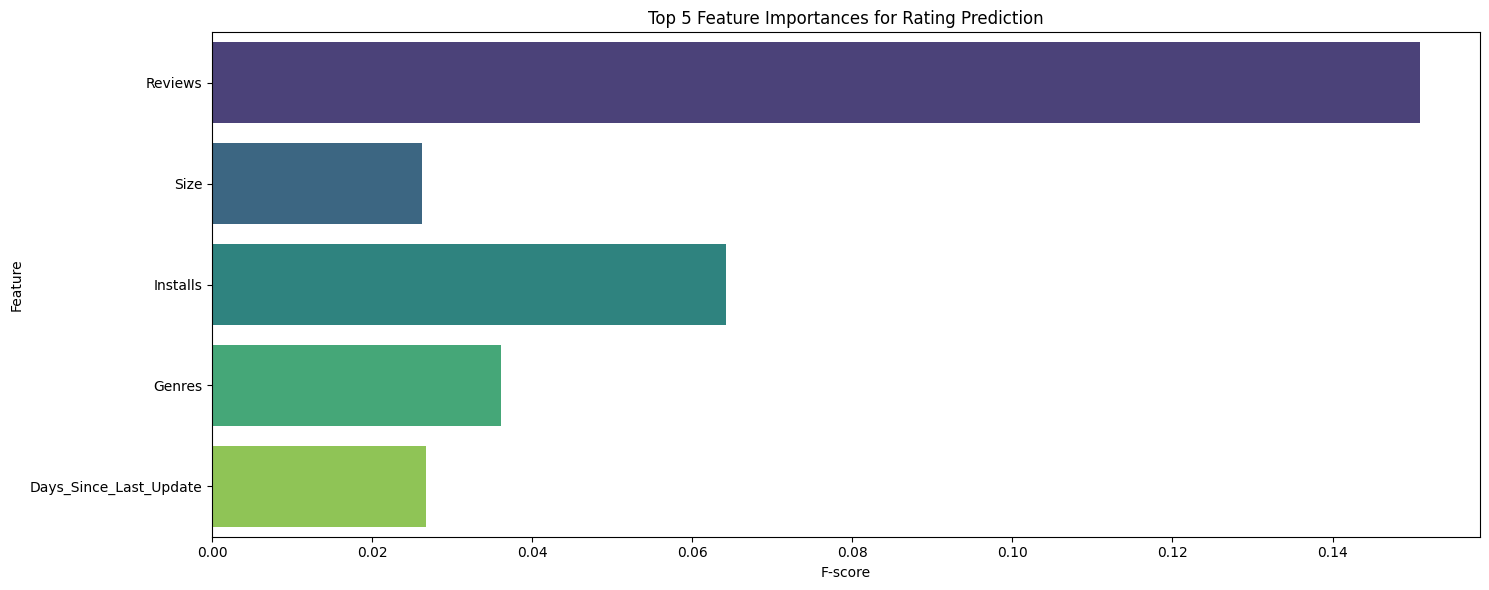

In [696]:
plt.figure(figsize=(15, 6))
sns.barplot(x=scores, y=top_features, palette="viridis")
plt.title("Top 5 Feature Importances for Rating Prediction")
plt.xlabel("F-score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

<a id="train_test_split"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#0066cc; overflow:hidden"><b>Train-Test Split for Model Training</b></div>


In [697]:
X=new_df.drop(columns=["Rating"],axis=1)
y=new_df["Rating"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<a id="catboost_classifier"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#ff9933; overflow:hidden"><b>Training the CatBoost Classifier</b></div>


In [698]:
model = CatBoostClassifier(verbose=100, learning_rate=0.5, random_state=42,iterations=1000,max_depth=6)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

0:	learn: 1.1375318	total: 8.11ms	remaining: 8.1s
100:	learn: 0.7220299	total: 523ms	remaining: 4.65s
200:	learn: 0.6084843	total: 1.04s	remaining: 4.13s
300:	learn: 0.5251893	total: 1.56s	remaining: 3.63s
400:	learn: 0.4596856	total: 2.1s	remaining: 3.13s
500:	learn: 0.4053737	total: 2.66s	remaining: 2.65s
600:	learn: 0.3629753	total: 3.19s	remaining: 2.12s
700:	learn: 0.3253341	total: 3.71s	remaining: 1.58s
800:	learn: 0.2929441	total: 4.24s	remaining: 1.05s
900:	learn: 0.2664594	total: 4.77s	remaining: 524ms
999:	learn: 0.2428853	total: 5.29s	remaining: 0us


<a id="catboost_metrics"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#3366cc; overflow:hidden"><b>📊 CatBoost Classifier Evaluation Metrics</b></div>

In [699]:
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
y_proba = model.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
kappa = cohen_kappa_score(y_test, y_pred)

print(f"Accuracy Score   : {acc:.4f}")
print(f"F1 Score         : {f1:.4f}")
print(f"Precision Score  : {precision:.4f}")
print(f"Recall Score     : {recall:.4f}")
print(f"ROC AUC Score    : {roc_auc:.4f}")
print(f"Cohen’s Kappa    : {kappa:.4f}")

Accuracy Score   : 0.6093
F1 Score         : 0.4404
Precision Score  : 0.4813
Recall Score     : 0.4244
ROC AUC Score    : 0.7735
Cohen’s Kappa    : 0.3125


<a id="confusion_matrix"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#6600cc; overflow:hidden"><b>Confusion Matrix</b></div>


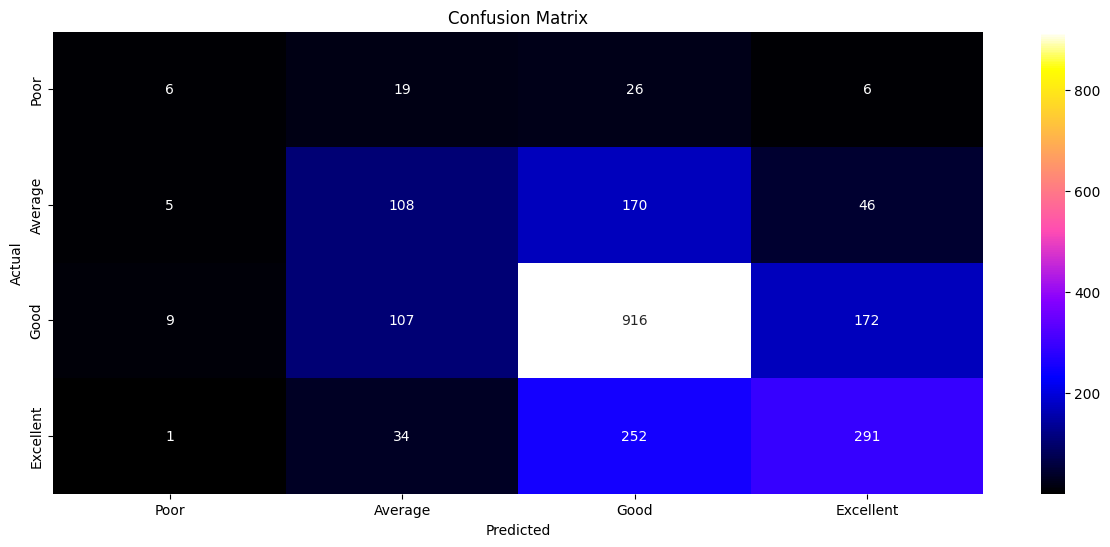

In [700]:
cm = confusion_matrix(y_test, y_pred)
label_name=["Poor","Average","Good","Excellent"]
plt.figure(figsize=(15,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='gnuplot2', xticklabels=label_name, yticklabels=label_name)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

<a id="classification_report"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#009999; overflow:hidden"><b>Classification Report</b></div>


In [701]:
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred,target_names=label_name)
print(report)

              precision    recall  f1-score   support

        Poor       0.29      0.11      0.15        57
     Average       0.40      0.33      0.36       329
        Good       0.67      0.76      0.71      1204
   Excellent       0.57      0.50      0.53       578

    accuracy                           0.61      2168
   macro avg       0.48      0.42      0.44      2168
weighted avg       0.59      0.61      0.60      2168



<a id="class_distribution"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#cc6600; overflow:hidden"><b>Distribution of Actual vs Predicted Classes</b></div>


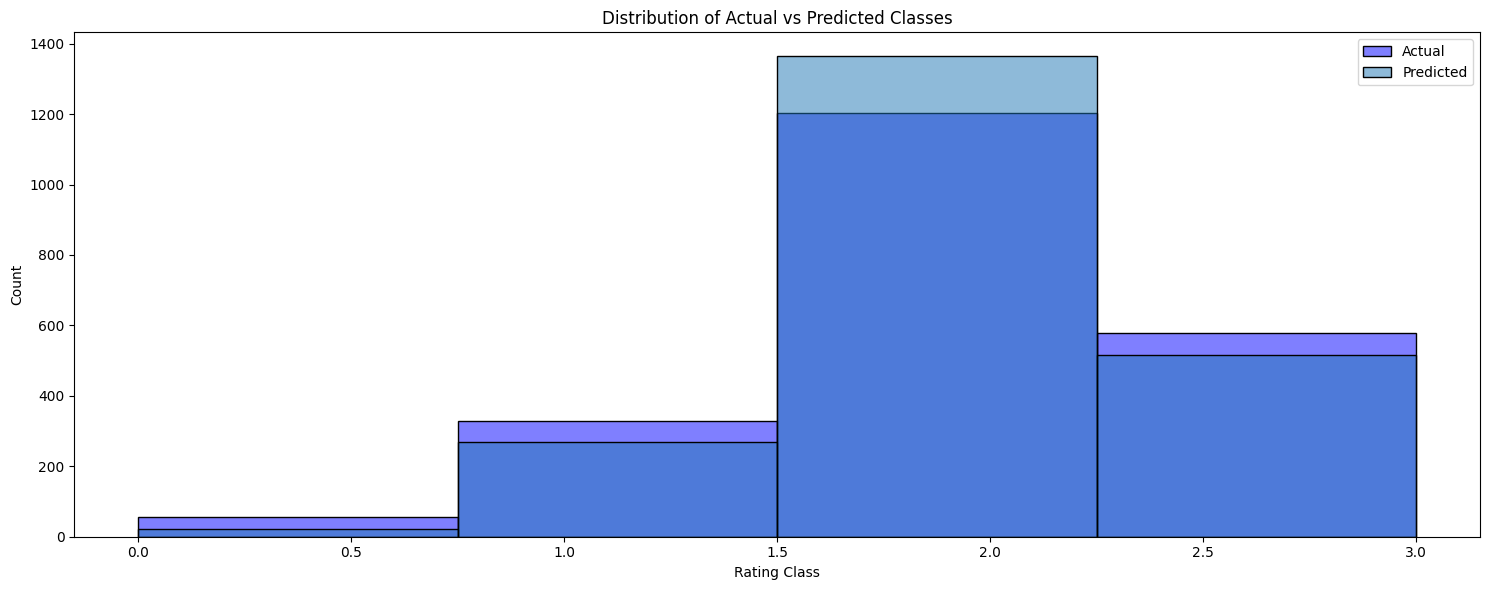

In [702]:
plt.figure(figsize=(15, 6))
classes = np.unique(y)
sns.histplot(y_test, label='Actual', color='blue', alpha=0.5, bins=len(classes))
sns.histplot(y_pred, label='Predicted', color='crimson', alpha=0.5, bins=len(classes))
plt.xlabel('Rating Class')
plt.title('Distribution of Actual vs Predicted Classes')
plt.legend()
plt.tight_layout()
plt.show()

<a id="probability_distribution"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#9932CC; overflow:hidden"><b>Distribution of Predicted Probabilities by Class</b></div>


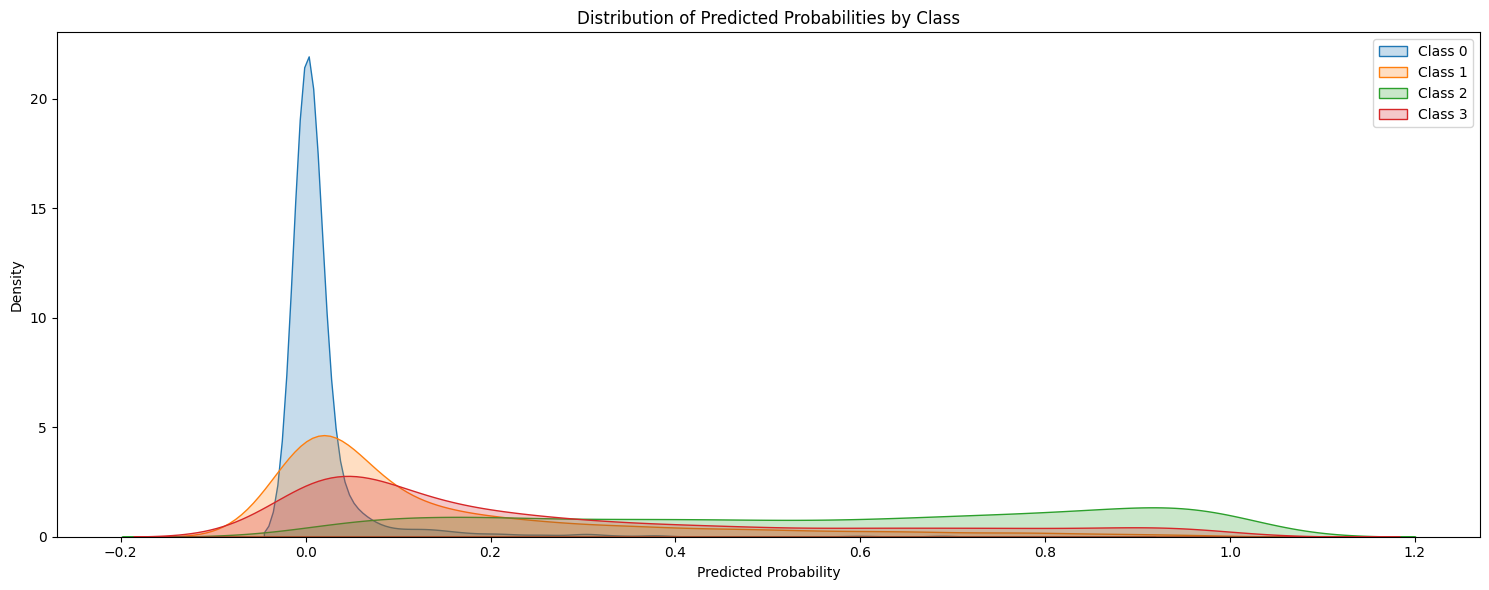

In [703]:
plt.figure(figsize=(15, 6))
y_pred_proba = model.predict_proba(X_test)

for i, cls in enumerate(classes):
    sns.kdeplot(y_pred_proba[:, i], label=f'Class {cls}', fill=True)
plt.xlabel('Predicted Probability')
plt.title('Distribution of Predicted Probabilities by Class')
plt.legend()
plt.tight_layout()
plt.show()

<a id="roc_curve"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#4682B4; overflow:hidden"><b>ROC Curve (One-vs-Rest)</b></div>


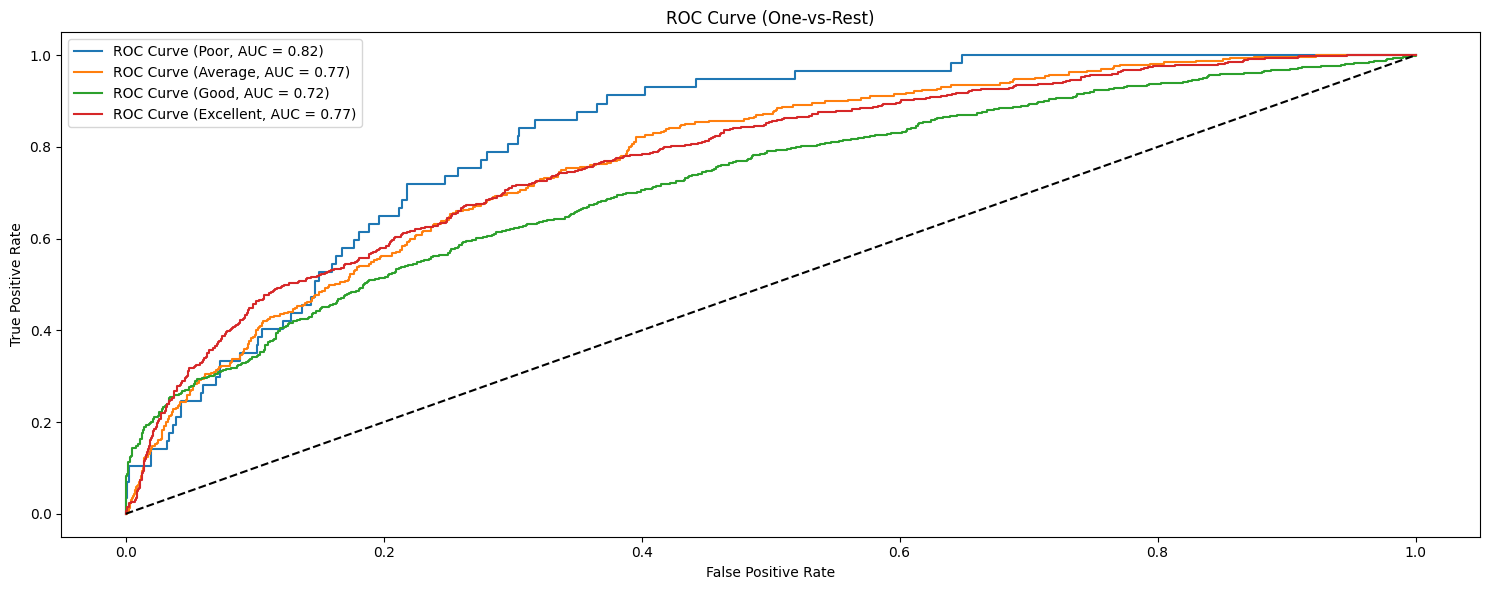

In [704]:
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, roc_curve, auc,
                         precision_recall_curve, average_precision_score)

from sklearn.preprocessing import label_binarize
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(15, 6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC Curve ({label_name[cls]}, AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest)')
plt.legend()
plt.tight_layout()
plt.show()

<a id="precision_recall_curve"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#FF6347; overflow:hidden"><b>Precision-Recall Curve (One-vs-Rest)</b></div>


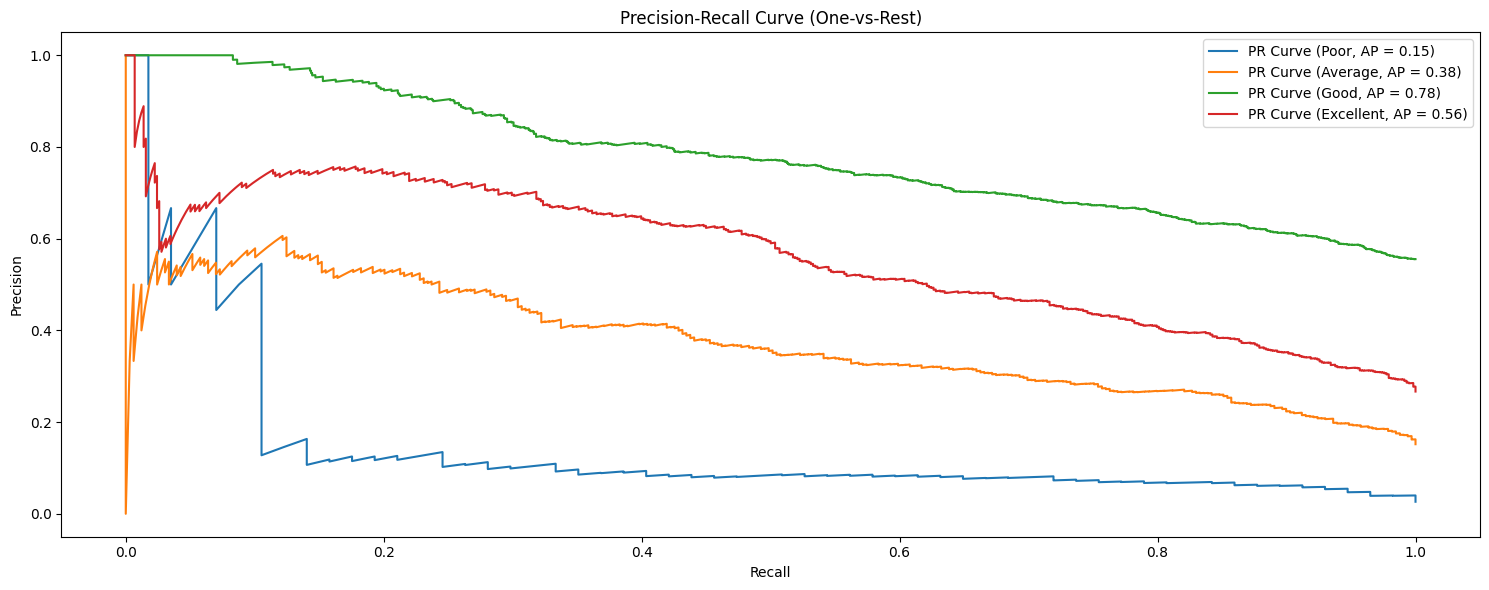

In [705]:
plt.figure(figsize=(15, 6))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])
    plt.plot(recall, precision, label=f'PR Curve ({label_name[cls]}, AP = {ap:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (One-vs-Rest)')
plt.legend()
plt.tight_layout()
plt.show()

<a id="interactive_roc_curve"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#4B0082; overflow:hidden"><b>Interactive ROC Curve (One-vs-Rest)</b></div>


In [706]:
fig = go.Figure()
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    fig.add_trace(go.Scatter(x=fpr, y=tpr, name=f'{label_name[cls]} (AUC = {roc_auc:.2f})', mode='lines'))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Random'))
fig.update_layout(title='Interactive ROC Curve (One-vs-Rest)',
                  xaxis_title='False Positive Rate',
                  yaxis_title='True Positive Rate')
fig.show()

<a id="interactive_confusion_matrix"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#2E8B57; overflow:hidden"><b>Interactive Confusion Matrix</b></div>


In [707]:
fig = px.imshow(cm, text_auto=True, x=label_name, y=label_name,
                labels=dict(x="Predicted", y="Actual", color="Count"),
                title="Interactive Confusion Matrix")
fig.show()

<a id="classification_errors"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#d32f2f; overflow:hidden"><b>Classification Errors</b></div>


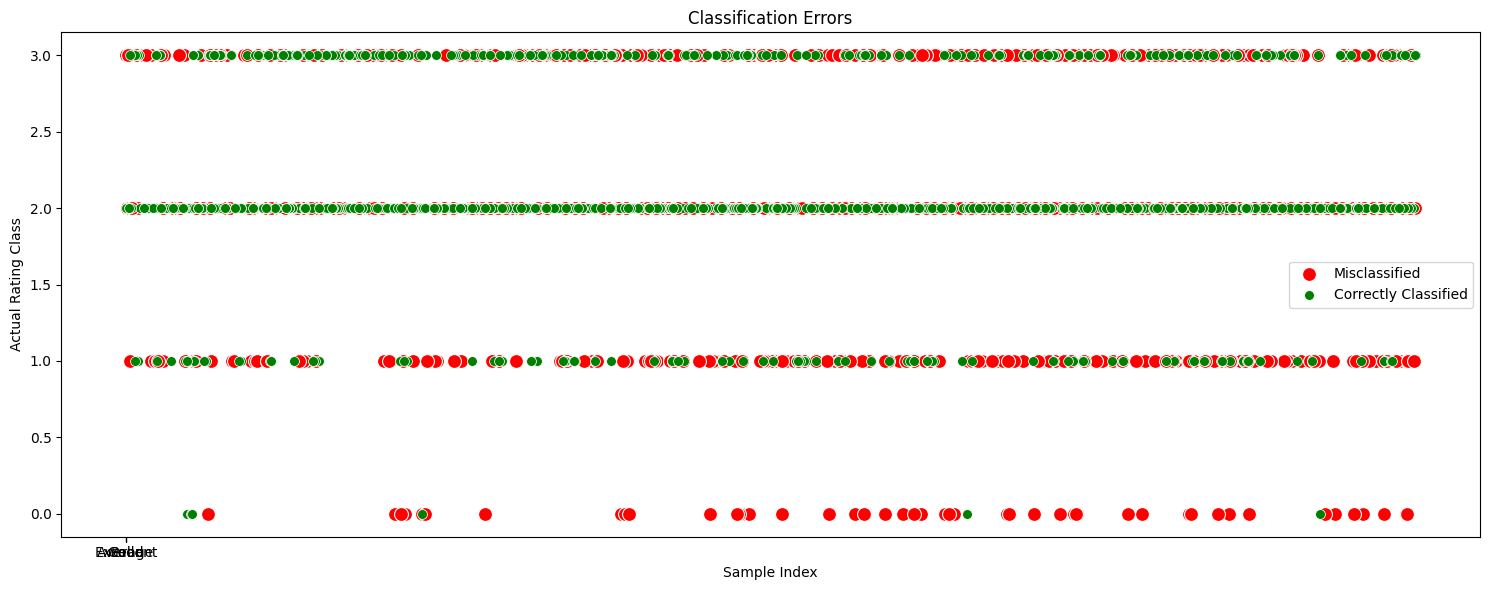

In [708]:
y_pred = model.predict(X_test).flatten()
errors = y_test != y_pred
plt.figure(figsize=(15, 6))
sns.scatterplot(x=X_test.index[errors], y=y_test[errors], color='red', label='Misclassified', s=100)
sns.scatterplot(x=X_test.index[~errors], y=y_test[~errors], color='green', label='Correctly Classified', s=50)
plt.xticks(ticks=classes, labels=label_name)
plt.xlabel('Sample Index')
plt.ylabel('Actual Rating Class')
plt.title('Classification Errors')
plt.legend()
plt.tight_layout()
plt.show()


<a id="pairplot_predicted_rating"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#00796B; overflow:hidden"><b>Pairplot of Features Colored by Predicted Rating</b></div>


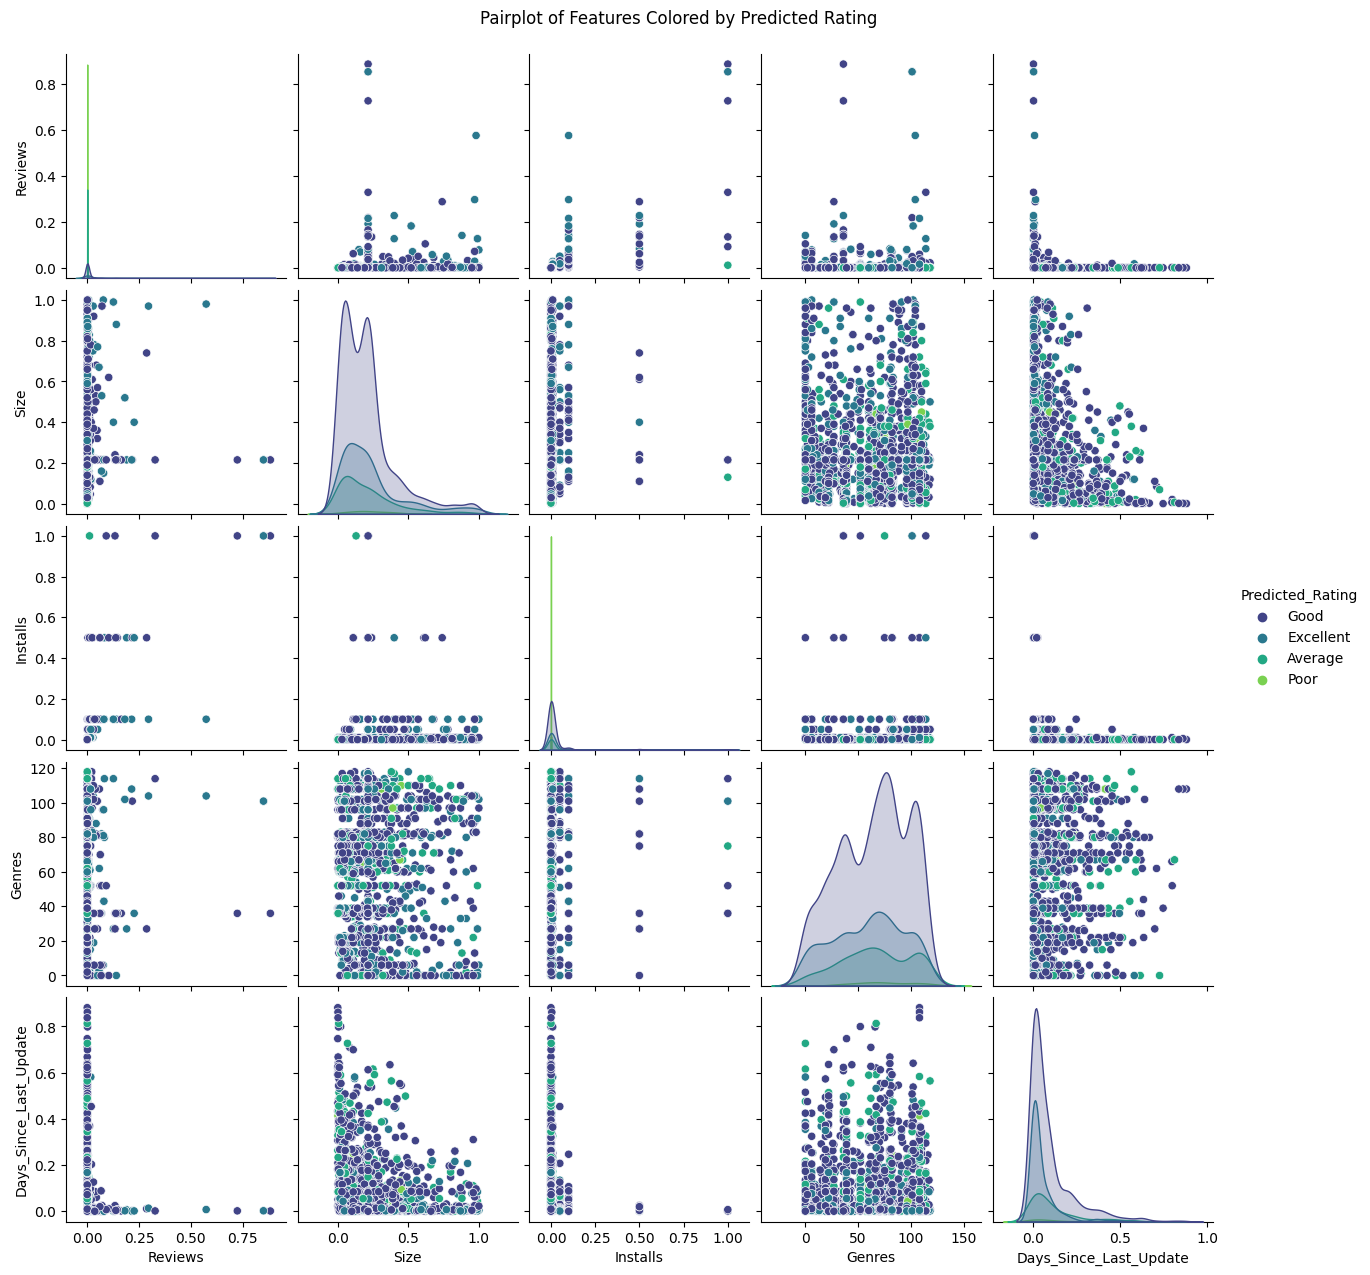

In [709]:
df_test = X_test.copy()
df_test['Predicted_Rating'] = [label_name[p] for p in y_pred]
sns.pairplot(df_test, hue='Predicted_Rating', palette='viridis')
plt.suptitle('Pairplot of Features Colored by Predicted Rating', y=1.02)
plt.show()

<a id="per_class_metrics"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#556B2F; overflow:hidden"><b>Per-Class Precision, Recall and F1-Score</b></div>


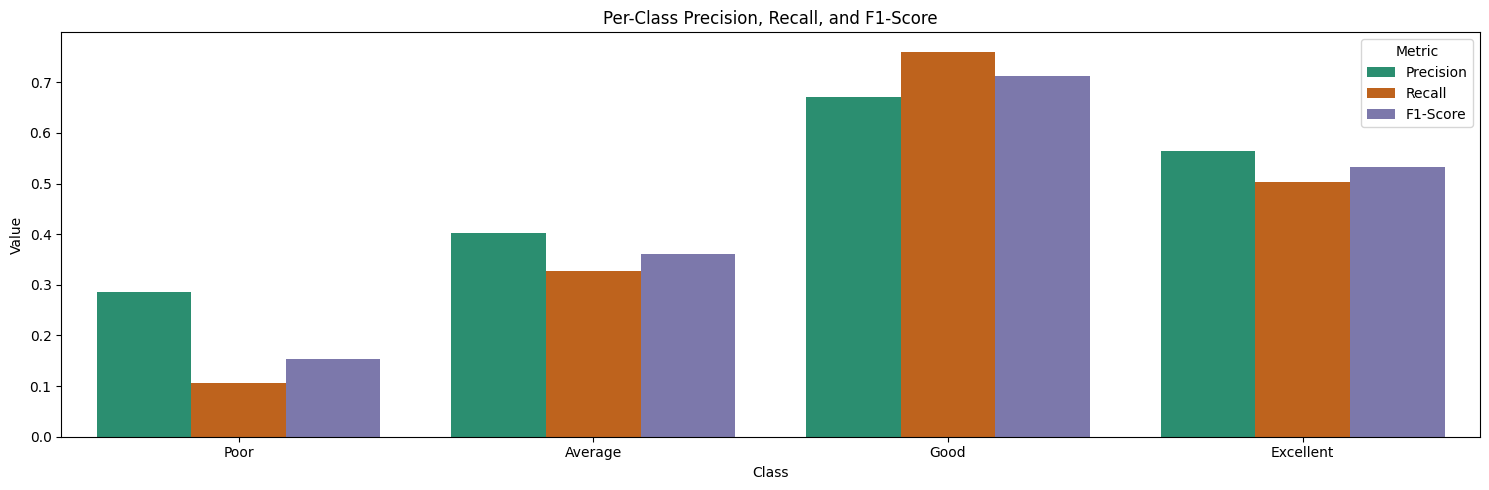

In [710]:
report = classification_report(y_test, y_pred, target_names=label_name, output_dict=True, zero_division=0)
metrics_df = pd.DataFrame({
    'Class': label_name,
    'Precision': [report[cls]['precision'] for cls in label_name],
    'Recall': [report[cls]['recall'] for cls in label_name],
    'F1-Score': [report[cls]['f1-score'] for cls in label_name]
})
metrics_df = metrics_df.melt(id_vars='Class', var_name='Metric', value_name='Value')
plt.figure(figsize=(15, 5))
sns.barplot(x='Class', y='Value', hue='Metric', data=metrics_df,palette="Dark2")
plt.title('Per-Class Precision, Recall, and F1-Score')
plt.tight_layout()
plt.show()

<a id="calibration_curve"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#FF8C00; overflow:hidden"><b>Calibration Curve (One-vs-Rest)</b></div>


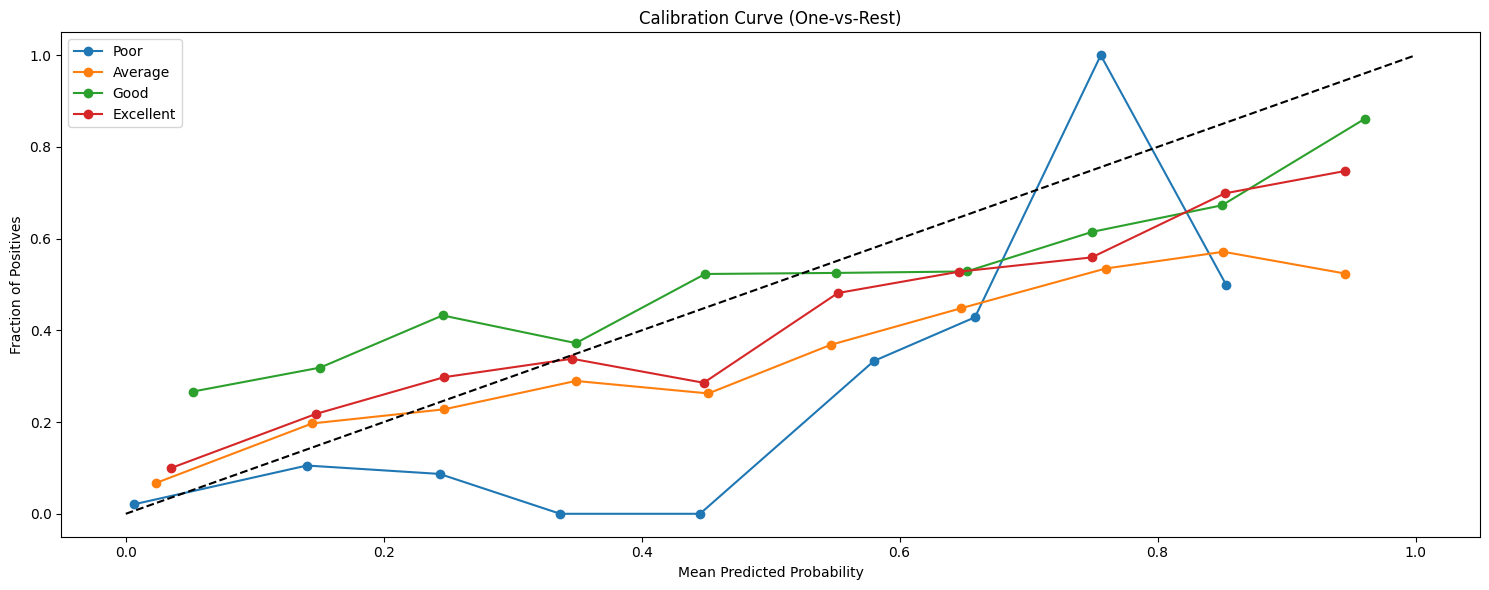

In [711]:
from sklearn.calibration import calibration_curve
plt.figure(figsize=(15, 6))
for i, cls in enumerate(classes):
    prob_true, prob_pred = calibration_curve(y_test_bin[:, i], y_pred_proba[:, i], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=f'{label_name[cls]}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (One-vs-Rest)')
plt.legend()
plt.tight_layout()
plt.show()

<a id="pca_projection"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#1E90FF; overflow:hidden"><b>Decision Boundary (PCA Projection of Test Data)</b></div>


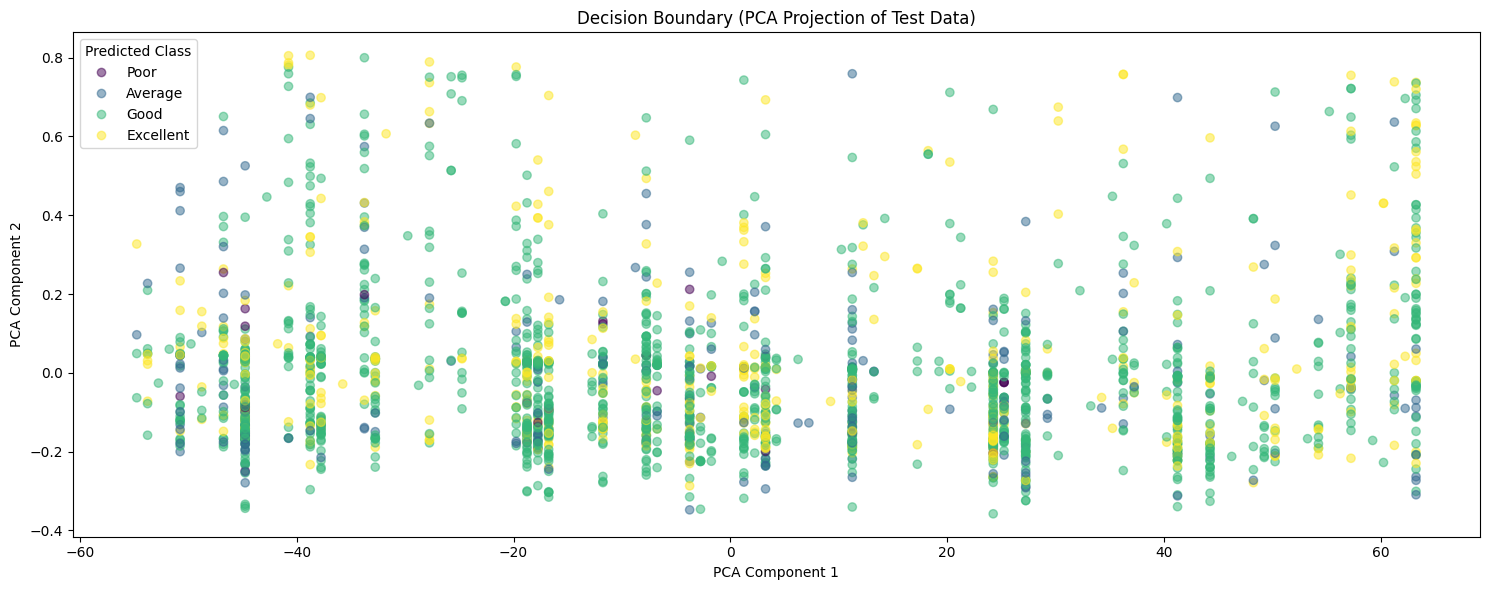

In [712]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)
plt.figure(figsize=(15, 6))
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='viridis', alpha=0.5)
plt.legend(handles=scatter.legend_elements()[0], labels=label_name, title="Predicted Class")
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Decision Boundary (PCA Projection of Test Data)')
plt.tight_layout()
plt.show()

<a id="top30_predicted_probabilities"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#8A2BE2; overflow:hidden"><b>Predicted Probabilities for Top 30 Samples (Test Set)</b></div>


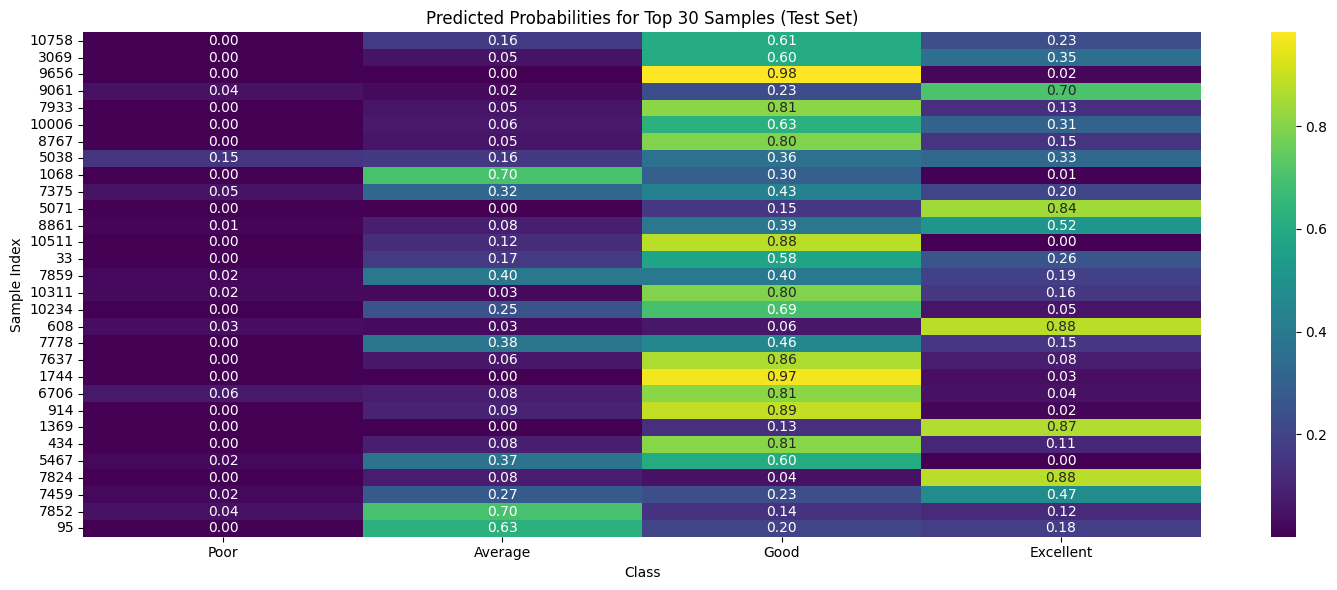

In [713]:
plt.figure(figsize=(15, 6))
top_30_indices = X_test.index[:30]
top_30_proba = y_pred_proba[:30]
sns.heatmap(top_30_proba, xticklabels=label_name, yticklabels=top_30_indices,cmap='viridis', annot=True, fmt='.2f')
plt.xlabel('Class')
plt.ylabel('Sample Index')
plt.title('Predicted Probabilities for Top 30 Samples (Test Set)')
plt.tight_layout()
plt.show()